In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [3]:
# recall vs qps on static datasets
# on SIFT/MSTuring Static sets
# surge & gp-ann
# TODO: compute imbalance information for both?
# surge
# 
# surge - to generate:
# ./bin/partitioning_quality to create the index
# mpirun -mca btl_tcp_if_include br-flat-lan-1 -np 10 --rankfile rankfile.txt taskset -c 0-31 ./bin/shared_static_experiment to measure qps and recall

# gp-ann - to generate:
#  ./Partition base-vectors.fbin out/partition 10 GP default
#  ./BuildRouter base-vectors.fbin out/partition.k=10.GP out/router.hnsw
#  mpirun -mca btl_tcp_if_include br-flat-lan-1 -np 10 --rankfile rankfile.txt taskset -c 0-31 ./release_l2/DistributedBench /dataset/big-ann-benchmarks/data/bigann/base.1B.crop_nb_100000000.u8bin /dataset/big-ann-benchmarks/data/bigann/query.public.10K.u8bin /dataset/big-ann-benchmarks/data/bigann/bigann-100M.ibin 10 /dataset/big-ann-benchmarks/data/bigann/gpann_partitions/bigann100M.k\=10.GP /dataset/big-ann-benchmarks/data/bigann/gpann_partitions/bigann100M.GP.router.hnsw

# TODO: generate gpann Pyramid partitions & check throguhput and recall for those as well

In [4]:
# inconsistent == built with code that did not zero out kmeans center counts, and used vertex weights for partitioning
# /dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results.csv
# /dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results_inconsistent.csv
# /dataset/surge/results/static_data_throughput/shared_static_experiment_sift100M_results_inconsistent.csv
# /dataset/surge/results/static_data_throughput/shared_static_experiment_sift500M_results_inconsistent.csv
# /dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results_32t.csv

In [5]:
surge_msturing100M_path = "/dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results_newer_unoptimized.csv"
surge_msturing100M = pd.read_csv(surge_msturing100M_path)

surge_msturing100M_path_optimized = "/dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results_newer.csv"
surge_msturing100M_optimized = pd.read_csv(surge_msturing100M_path_optimized)

surge_msturing100M_path_reverted = "/dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results_newer_unoptimized.csv"
surge_msturing100M_reverted = pd.read_csv(surge_msturing100M_path_reverted)

# surge_msturing100M_inconsistent_path = "/users/dkhimey/surge/shared_static_experiment_msturing100M_results_inconsistent.csv"
# surge_msturing100M_inconsistent = pd.read_csv(surge_msturing100M_inconsistent_path)

gpann_msturing100M_path = "/dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/distributed_bench_results_msturing100M_withrouting_newer.csv"
gpann_msturing100M = pd.read_csv(gpann_msturing100M_path)


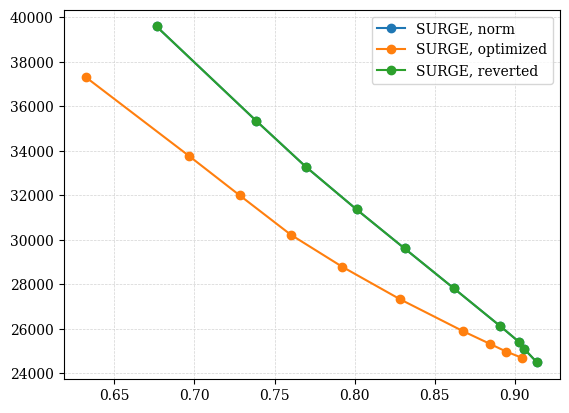

In [6]:
plt.plot(surge_msturing100M[surge_msturing100M["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "RecallTarget"]["qps"],
            marker="o", label="SURGE, norm")

plt.plot(surge_msturing100M_optimized[surge_msturing100M_optimized["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing100M_optimized[surge_msturing100M_optimized["mode"] == "RecallTarget"]["qps"],
            marker="o", label="SURGE, optimized")

plt.plot(surge_msturing100M_reverted[surge_msturing100M_reverted["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing100M_reverted[surge_msturing100M_reverted["mode"] == "RecallTarget"]["qps"],
            marker="o", label="SURGE, reverted")

# add grid
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.legend()



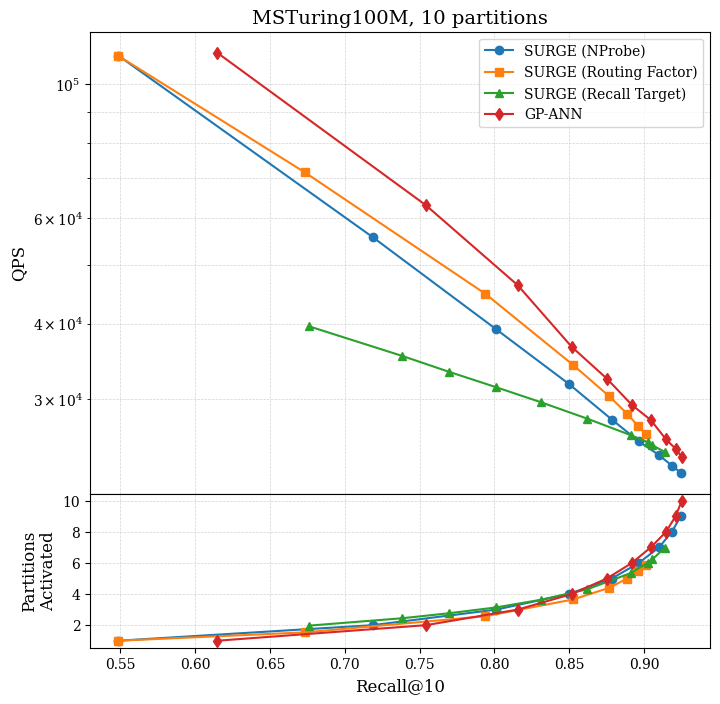

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
ax1.plot(surge_msturing100M[surge_msturing100M["mode"] == "NProbe"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "NProbe"]["qps"],
            marker="o", label="SURGE (NProbe)")

ax1.plot(surge_msturing100M[surge_msturing100M["mode"] == "BranchingFactor"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "BranchingFactor"]["qps"],
            marker="s", label="SURGE (Routing Factor)")

ax1.plot(surge_msturing100M[surge_msturing100M["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "RecallTarget"]["qps"],
            marker="^", label="SURGE (Recall Target)")

ax1.plot(gpann_msturing100M["recall@10"], gpann_msturing100M["qps"], marker="d", label="GP-ANN")

ax1.set_title("MSTuring100M, 10 partitions")
# ax1.set_xlabel("Recall@10")
ax1.set_ylabel("QPS")

ax1.legend()

ax1.set_yscale("log")

ax2.plot(surge_msturing100M[surge_msturing100M["mode"] == "NProbe"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "NProbe"]["avg_parts_searched"],
            marker="o", label="SURGE (NProbe)")

ax2.plot(surge_msturing100M[surge_msturing100M["mode"] == "BranchingFactor"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "BranchingFactor"]["avg_parts_searched"],
            marker="s", label="SURGE (Routing Factor)")

ax2.plot(surge_msturing100M[surge_msturing100M["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing100M[surge_msturing100M["mode"] == "RecallTarget"]["avg_parts_searched"],
            marker="^", label="SURGE (Recall Target)")

ax2.plot(gpann_msturing100M["recall@10"], gpann_msturing100M["nprobe"], marker="d", label="GP-ANN")

ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)

ax2.set_ylabel("Partitions\nActivated")
ax2.set_xlabel("Recall@10")

# save
plt.savefig("msturing100M_qps_analysis.pdf", bbox_inches="tight")

In [10]:
surge_bigann100M_path = "/dataset/surge/results/static_data_throughput/shared_static_experiment_sift100M_results_newer_unoptimized.csv"
surge_bigann100M = pd.read_csv(surge_bigann100M_path)

gpann_bigann100M_path = "/dataset/big-ann-benchmarks/data/bigann/gpann_partitions/distributed_bench_results_bigann100M_withrouting_newer.csv"
gpann_bigann100M = pd.read_csv(gpann_bigann100M_path)

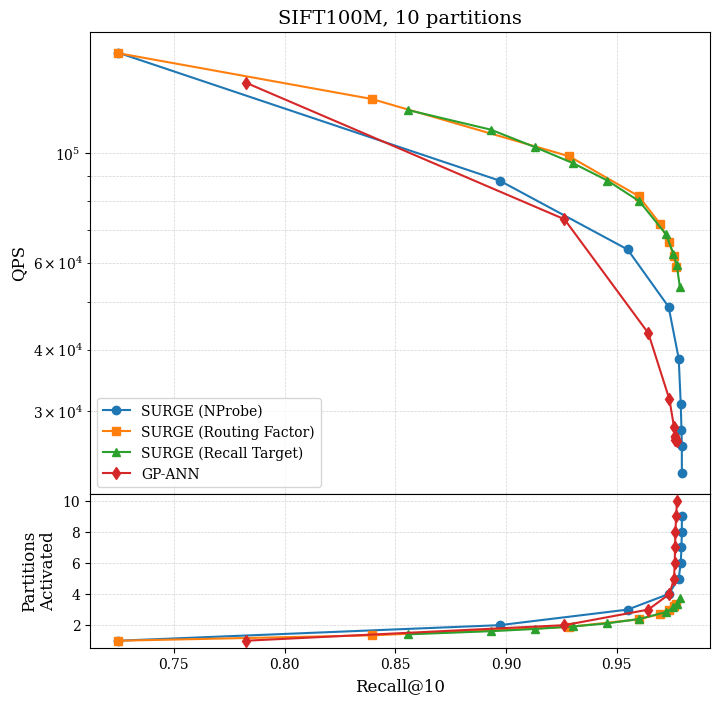

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.plot(surge_bigann100M[surge_bigann100M["mode"] == "NProbe"]["recall@10"],
            surge_bigann100M[surge_bigann100M["mode"] == "NProbe"]["qps"],
            marker="o", label="SURGE (NProbe)")

ax1.plot(surge_bigann100M[surge_bigann100M["mode"] == "BranchingFactor"]["recall@10"],
            surge_bigann100M[surge_bigann100M["mode"] == "BranchingFactor"]["qps"],
            marker="s", label="SURGE (Routing Factor)")

ax1.plot(surge_bigann100M[surge_bigann100M["mode"] == "RecallTarget"]["recall@10"],
            surge_bigann100M[surge_bigann100M["mode"] == "RecallTarget"]["qps"],
            marker="^", label="SURGE (Recall Target)")

ax1.plot(gpann_bigann100M["recall@10"], gpann_bigann100M["qps"], marker="d", label="GP-ANN")

ax1.set_title("SIFT100M, 10 partitions")
# ax1.set_xlabel("Recall@10")
ax1.set_ylabel("QPS")

ax1.legend()
ax1.set_yscale("log")


ax2.plot(surge_bigann100M[surge_bigann100M["mode"] == "NProbe"]["recall@10"],
            surge_bigann100M[surge_bigann100M["mode"] == "NProbe"]["avg_parts_searched"],
            marker="o", label="SURGE (NProbe)")

ax2.plot(surge_bigann100M[surge_bigann100M["mode"] == "BranchingFactor"]["recall@10"],
            surge_bigann100M[surge_bigann100M["mode"] == "BranchingFactor"]["avg_parts_searched"],
            marker="s", label="SURGE (Routing Factor)")

ax2.plot(surge_bigann100M[surge_bigann100M["mode"] == "RecallTarget"]["recall@10"],
            surge_bigann100M[surge_bigann100M["mode"] == "RecallTarget"]["avg_parts_searched"],
            marker="^", label="SURGE (Recall Target)")

ax2.plot(gpann_bigann100M["recall@10"], gpann_bigann100M["nprobe"], marker="d", label="GP-ANN")

ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)

ax2.set_ylabel("Partitions\nActivated")
ax2.set_xlabel("Recall@10")

# save
plt.savefig("sift100M_qps_analysis.pdf", bbox_inches="tight")

In [12]:
surge_bigann500M_path = "/dataset/surge/results/static_data_throughput/shared_static_experiment_sift500M_results_newer_unoptimized.csv"
surge_bigann500M = pd.read_csv(surge_bigann500M_path)

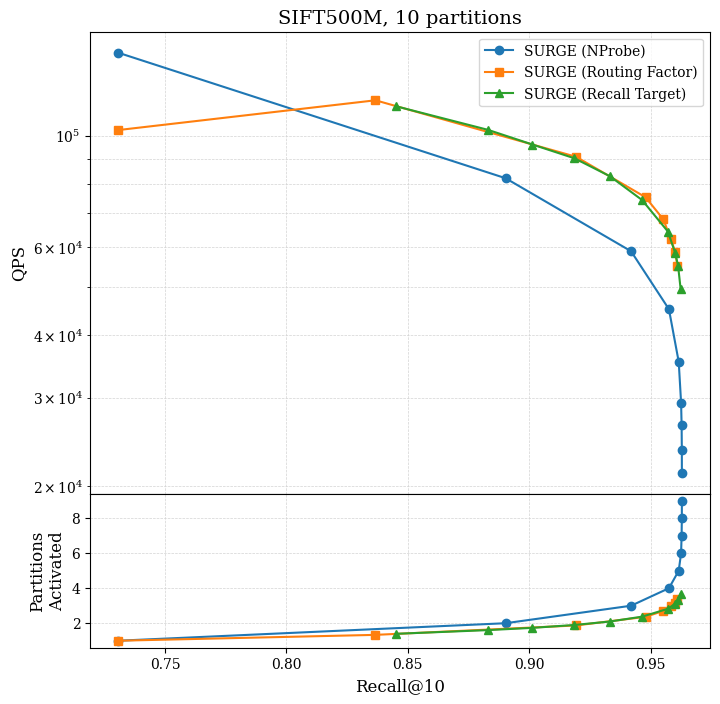

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
ax1.plot(surge_bigann500M[surge_bigann500M["mode"] == "NProbe"]["recall@10"],
            surge_bigann500M[surge_bigann500M["mode"] == "NProbe"]["qps"],
            marker="o", label="SURGE (NProbe)")

ax1.plot(surge_bigann500M[surge_bigann500M["mode"] == "BranchingFactor"]["recall@10"],
            surge_bigann500M[surge_bigann500M["mode"] == "BranchingFactor"]["qps"],
            marker="s", label="SURGE (Routing Factor)")

ax1.plot(surge_bigann500M[surge_bigann500M["mode"] == "RecallTarget"]["recall@10"],
            surge_bigann500M[surge_bigann500M["mode"] == "RecallTarget"]["qps"],
            marker="^", label="SURGE (Recall Target)")

ax1.set_title("SIFT500M, 10 partitions")
# ax1.set_xlabel("Recall@10")
ax1.set_ylabel("QPS")

ax1.legend()

ax1.set_yscale("log")

ax2.plot(surge_bigann500M[surge_bigann500M["mode"] == "NProbe"]["recall@10"],
            surge_bigann500M[surge_bigann500M["mode"] == "NProbe"]["avg_parts_searched"],
            marker="o", label="SURGE (NProbe)")

ax2.plot(surge_bigann500M[surge_bigann500M["mode"] == "BranchingFactor"]["recall@10"],
            surge_bigann500M[surge_bigann500M["mode"] == "BranchingFactor"]["avg_parts_searched"],
            marker="s", label="SURGE (Routing Factor)")

ax2.plot(surge_bigann500M[surge_bigann500M["mode"] == "RecallTarget"]["recall@10"],
            surge_bigann500M[surge_bigann500M["mode"] == "RecallTarget"]["avg_parts_searched"],
            marker="^", label="SURGE (Recall Target)")

ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)

ax2.set_ylabel("Partitions\nActivated")
ax2.set_xlabel("Recall@10")

# save
plt.savefig("sift500M_qps_analysis.pdf", bbox_inches="tight")

In [14]:
surge_msturing500M_path = "/dataset/surge/results/static_data_throughput/shared_static_experiment_msturing500M_results_newer_unoptimized.csv"
surge_msturing500M = pd.read_csv(surge_msturing500M_path)

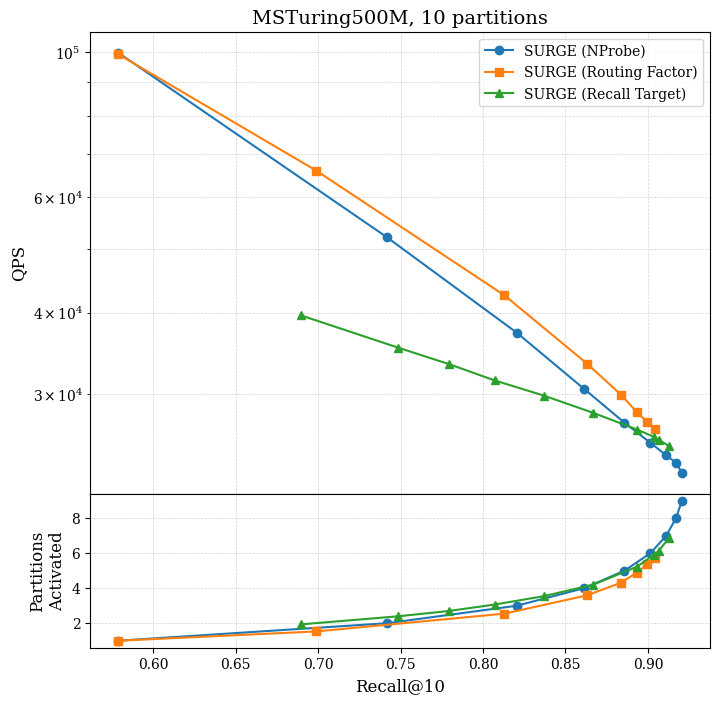

In [15]:
# fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.plot(surge_msturing500M[surge_msturing500M["mode"] == "NProbe"]["recall@10"],
            surge_msturing500M[surge_msturing500M["mode"] == "NProbe"]["qps"],
            marker="o", label="SURGE (NProbe)")

ax1.plot(surge_msturing500M[surge_msturing500M["mode"] == "BranchingFactor"]["recall@10"],
            surge_msturing500M[surge_msturing500M["mode"] == "BranchingFactor"]["qps"],
            marker="s", label="SURGE (Routing Factor)")

ax1.plot(surge_msturing500M[surge_msturing500M["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing500M[surge_msturing500M["mode"] == "RecallTarget"]["qps"],
            marker="^", label="SURGE (Recall Target)")

ax1.set_title("MSTuring500M, 10 partitions")
ax1.set_ylabel("QPS")

ax1.legend()

ax1.set_yscale("log")

# Bottom panel - ready for content
ax2.plot(surge_msturing500M[surge_msturing500M["mode"] == "NProbe"]["recall@10"],
            surge_msturing500M[surge_msturing500M["mode"] == "NProbe"]["avg_parts_searched"],
            marker="o", label="SURGE (NProbe)")

ax2.plot(surge_msturing500M[surge_msturing500M["mode"] == "BranchingFactor"]["recall@10"],
            surge_msturing500M[surge_msturing500M["mode"] == "BranchingFactor"]["avg_parts_searched"],
            marker="s", label="SURGE (Routing Factor)")

ax2.plot(surge_msturing500M[surge_msturing500M["mode"] == "RecallTarget"]["recall@10"],
            surge_msturing500M[surge_msturing500M["mode"] == "RecallTarget"]["avg_parts_searched"],
            marker="^", label="SURGE (Recall Target)")
ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)

ax2.set_ylabel("Partitions\nActivated")
ax2.set_xlabel("Recall@10")

# save
plt.savefig("msturing500M_qps_analysis.pdf", bbox_inches="tight")